In [2]:
"""
=============================================================================
RESEARCH QUESTION:
Is early waking independently associated with better mental well-being and productivity outcomes, or is this relationship mediated by sleep quality, exercise habits, and other lifestyle factors?

DATASET: Early Wakeup Health & Lifestyle Dataset (synthetic, 10,000 rows)

WHAT THIS SCRIPT DOES, STEP BY STEP:
1.  Load and inspect the data
2.  Clean it (missing values, encode the target)
3.  Explore it visually (EDA)
4.  Test whether early wakers and non-early wakers differ statistically on
    well-being / productivity outcomes (t-test / Mann-Whitney + effect size)
5.  Run a formal MEDIATION ANALYSIS (Baron & Kenny approach + bootstrap) to
    test whether sleep quality / exercise explain away the early-waking
    effect, which is the actual core of the research question
6.  Build a predictive model of Early_Waker as a secondary, supporting task
    (feature importance tells us which lifestyle factors matter most)
7.  Summarise everything in plain language at the end
=============================================================================
"""

'\n=============================================================================\nRESEARCH QUESTION:\nIs early waking independently associated with better mental well-being and productivity outcomes, or is this relationship mediated by sleep quality, exercise habits, and other lifestyle factors?\n\nDATASET: Early Wakeup Health & Lifestyle Dataset (synthetic, 10,000 rows)\n\nWHAT THIS SCRIPT DOES, STEP BY STEP:\n1.  Load and inspect the data\n2.  Clean it (missing values, encode the target)\n3.  Explore it visually (EDA)\n4.  Test whether early wakers and non-early wakers differ statistically on\n    well-being / productivity outcomes (t-test / Mann-Whitney + effect size)\n5.  Run a formal MEDIATION ANALYSIS (Baron & Kenny approach + bootstrap) to\n    test whether sleep quality / exercise explain away the early-waking\n    effect, which is the actual core of the research question\n6.  Build a predictive model of Early_Waker as a secondary, supporting task\n    (feature importance tells

In [3]:
# -----------------------------------------------------------------------
# We import only well-established libraries that ship with a standard
# Anaconda / pip data-science install -- no exotic dependencies needed.
# -----------------------------------------------------------------------
import numpy as np                          # numerical arrays, linear algebra
import pandas as pd                         # tabular data handling
import matplotlib.pyplot as plt             # plotting
import seaborn as sns                       # nicer statistical plots
from scipy import stats                     # t-tests, Mann-Whitney, normality tests

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

sns.set_style("whitegrid")
RANDOM_STATE = 42   # fixed seed so results are reproducible every run

In [4]:
# -----------------------------------------------------------------------
# STEP 1: CONFIGURATION -- edit this section to match your actual CSV
# -----------------------------------------------------------------------
DATA_PATH = "early_wakeup_health_dataset.csv"   # <-- change to your file path

TARGET = "Early_Waker"                # the binary outcome we predict (Yes/No)

# Candidate mediators: variables that might "explain away" the effect of
# early waking on well-being / productivity
MEDIATORS = ["Sleep_Quality_Score", "Exercise_Frequency_Per_Week"]

# Outcome variables representing "mental well-being" and "productivity"
OUTCOMES = ["Mood_Score", "Life_Satisfaction_Score", "Productivity_Score"]

# Columns that are identifiers / free text and should be dropped if present
DROP_COLS = ["Person_ID"]

In [5]:
# -----------------------------------------------------------------------
# STEP 2: LOAD DATA
# -----------------------------------------------------------------------
df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("STEP 2: RAW DATA OVERVIEW")
print("=" * 70)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumn names (check these against the CONFIG section above):")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)

STEP 2: RAW DATA OVERVIEW
Shape: 10000 rows, 64 columns

Column names (check these against the CONFIG section above):
['Person_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Country', 'Occupation', 'Marital_Status', 'Wake_Up_Time', 'Sleep_Time', 'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Number_of_Night_Awakenings', 'Weekend_Sleep_Difference_Hours', 'Nap_Frequency_Per_Week', 'Screen_Time_Before_Bed_Hours', 'Exercise_Frequency_Per_Week', 'Exercise_Duration_Minutes', 'Exercise_Type', 'Daily_Steps', 'Morning_Workout', 'Workout_Intensity', 'Gym_Member', 'Daily_Calorie_Intake', 'Water_Intake_Liters', 'Fruit_Intake_Per_Day', 'Vegetable_Intake_Per_Day', 'Protein_Intake_Grams', 'Sugary_Drinks_Per_Week', 'Fast_Food_Meals_Per_Week', 'Breakfast_Regularity_Score', 'Smoking_Status', 'Alcohol_Consumption', 'Stress_Level', 'Working_Hours_Per_Day', 'Sitting_Hours_Per_Day', 'Outdoor_Time_Hours', 'Social_Interaction_Score', 'Meditation_Practice', 'Resting_Heart_Rate', 'Systolic_BP', 'Diast

In [6]:
# -----------------------------------------------------------------------
# STEP 3: CLEAN THE DATA
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 3: DATA CLEANING")
print("=" * 70)

# 3a. Drop pure identifier columns if they exist (they carry no signal)
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# 3b. Report missing values so we know what we're dealing with before fixing it
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values per column (before cleaning):")
print(missing if len(missing) else "None found.")

# 3c. Encode the target as binary (1 = Early Waker, 0 = Not an Early Waker).
# Models and statistics need numbers, not the strings "Yes"/"No". We check
# with pd.api.types.is_numeric_dtype (rather than dtype == object) because
# different pandas versions represent text columns differently.
if not pd.api.types.is_numeric_dtype(df[TARGET]):
    df[TARGET] = df[TARGET].astype(str).str.strip().str.lower().map(
        {"yes": 1, "no": 0}
    )

# 3d. Separate numeric and categorical columns automatically.
# This lets the script adapt even if the real dataset's column names differ
# slightly from our guesses, as long as the data TYPES are sensible.
# We deliberately split by "is this numeric or not" rather than relying on
# select_dtypes(include=["object"]), since newer pandas versions can store
# text as a dedicated "string" dtype instead of "object".
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)
categorical_cols = [c for c in df.columns if c not in numeric_cols and c != TARGET]

print(f"\nDetected {len(numeric_cols)} numeric columns and "
      f"{len(categorical_cols)} categorical columns.")

# 3e. Impute missing numeric values with the column median (robust to
# outliers, unlike the mean) and missing categorical values with the mode.
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# 3f. Drop any rows where the target itself is missing -- we can't use
# these for either the statistical tests or the model.
df = df.dropna(subset=[TARGET])
df[TARGET] = df[TARGET].astype(int)

print(f"\nShape after cleaning: {df.shape}")
print(f"Early_Waker distribution:\n{df[TARGET].value_counts(normalize=True)}")


STEP 3: DATA CLEANING
Missing values per column (before cleaning):
Exercise_Type           824
Workout_Intensity       824
Alcohol_Consumption    3014
dtype: int64

Detected 42 numeric columns and 20 categorical columns.

Shape after cleaning: (10000, 63)
Early_Waker distribution:
Early_Waker
0    0.5842
1    0.4158
Name: proportion, dtype: float64



STEP 4: EXPLORATORY DATA ANALYSIS


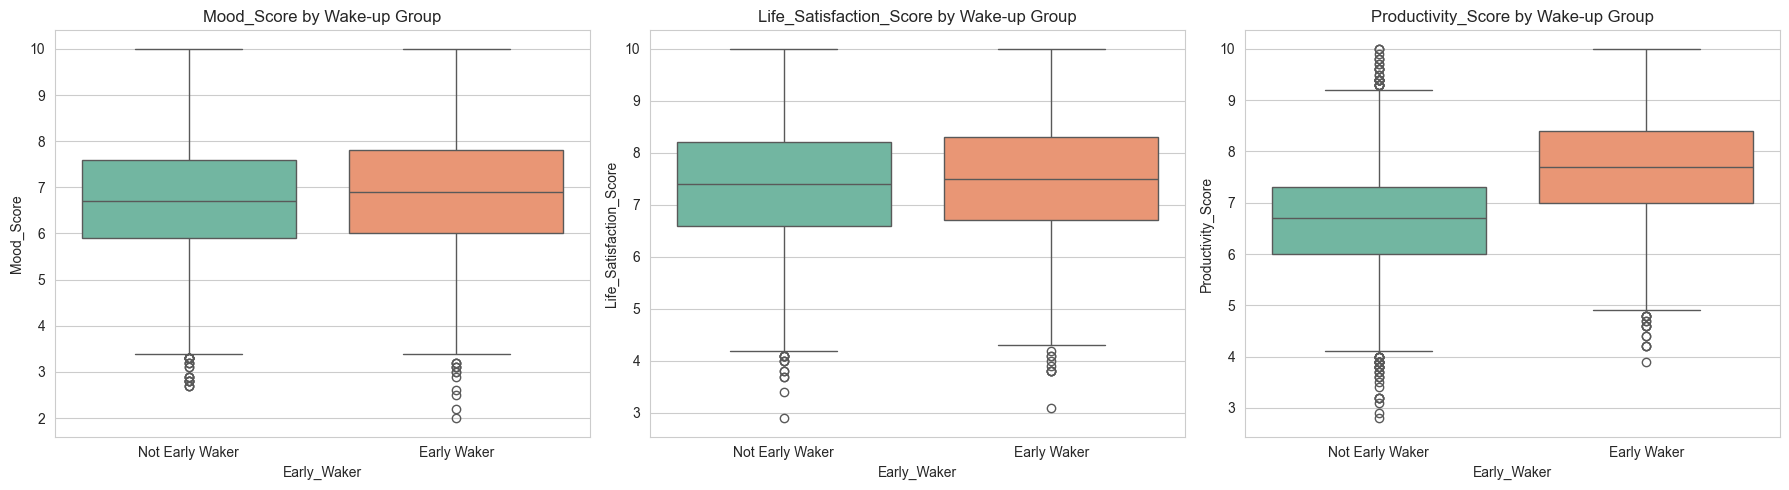

Saved: eda_outcomes_by_group.png (boxplots comparing each outcome between the two groups)


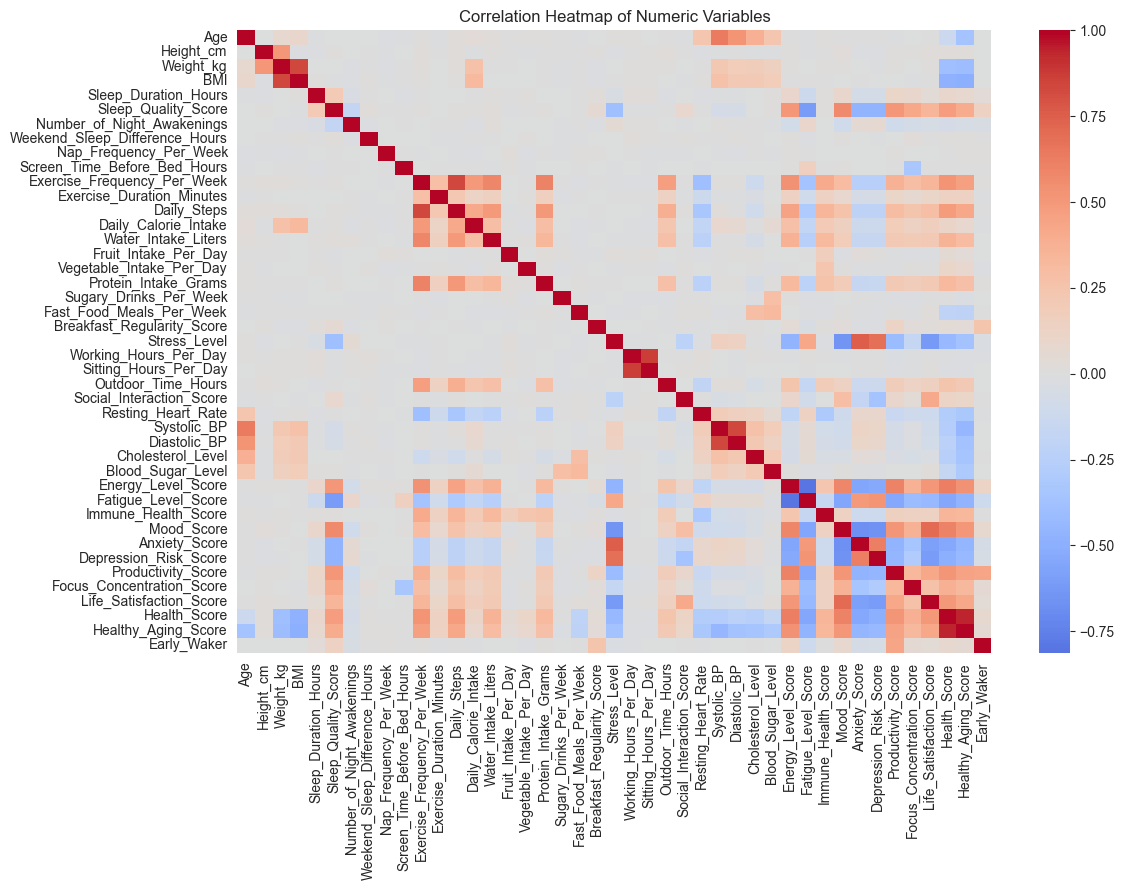

Saved: eda_correlation_heatmap.png


In [7]:
# -----------------------------------------------------------------------
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 4: EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# 4a. Visualise how each outcome differs between early wakers and others.
# Boxplots show median, spread, and outliers side by side for both groups.
fig, axes = plt.subplots(1, len(OUTCOMES), figsize=(6 * len(OUTCOMES), 5))
if len(OUTCOMES) == 1:
    axes = [axes]
for ax, outcome in zip(axes, OUTCOMES):
    sns.boxplot(data=df, x=TARGET, y=outcome, hue=TARGET, palette="Set2",
                legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Not Early Waker", "Early Waker"])
    ax.set_title(f"{outcome} by Wake-up Group")
plt.tight_layout()
plt.savefig("eda_outcomes_by_group.png", dpi=150)
plt.show()
print("Saved: eda_outcomes_by_group.png "
      "(boxplots comparing each outcome between the two groups)")

# 4b. Correlation heatmap of numeric variables. This gives a first visual
# hint of which lifestyle variables move together (e.g. does sleep quality
# correlate strongly with mood, independent of wake-up time?).
plt.figure(figsize=(12, 9))
corr = df[numeric_cols + [TARGET]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: eda_correlation_heatmap.png")

In [8]:
# -----------------------------------------------------------------------
# STEP 5: GROUP COMPARISON STATISTICAL TESTS
# Before doing mediation, we first confirm there IS a raw (total) difference
# worth explaining. We test each outcome between the two Early_Waker groups.
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 5: STATISTICAL GROUP COMPARISON (Early Wakers vs Others)")
print("=" * 70)

def compare_groups(data, outcome_col, group_col):
    """
    Compares an outcome variable between the two groups defined by
    group_col (0/1). Chooses the appropriate test based on a normality
    check, and reports an effect size (Cohen's d) so we know not just
    WHETHER a difference exists, but how big it is.
    """
    group0 = data.loc[data[group_col] == 0, outcome_col].dropna()
    group1 = data.loc[data[group_col] == 1, outcome_col].dropna()

    # Shapiro-Wilk tests whether each group looks normally distributed.
    # (On large samples this test is very sensitive, so we treat it as a
    # guide rather than an absolute rule.)
    _, p_norm0 = stats.shapiro(group0.sample(min(500, len(group0)), random_state=RANDOM_STATE))
    _, p_norm1 = stats.shapiro(group1.sample(min(500, len(group1)), random_state=RANDOM_STATE))
    normal_enough = (p_norm0 > 0.05) and (p_norm1 > 0.05)

    if normal_enough:
        stat, p_value = stats.ttest_ind(group1, group0, equal_var=False)
        test_used = "Welch's t-test"
    else:
        stat, p_value = stats.mannwhitneyu(group1, group0, alternative="two-sided")
        test_used = "Mann-Whitney U test"

    # Cohen's d: standardised mean difference, a common effect-size metric.
    # d ~ 0.2 small, ~0.5 medium, ~0.8 large (rule of thumb, not a hard law).
    pooled_std = np.sqrt(((len(group1) - 1) * group1.std()**2 +
                           (len(group0) - 1) * group0.std()**2) /
                          (len(group1) + len(group0) - 2))
    cohens_d = (group1.mean() - group0.mean()) / pooled_std

    return {
        "outcome": outcome_col,
        "test": test_used,
        "early_waker_mean": round(group1.mean(), 2),
        "non_early_waker_mean": round(group0.mean(), 2),
        "p_value": round(p_value, 4),
        "cohens_d": round(cohens_d, 3),
        "significant": p_value < 0.05,
    }

group_results = pd.DataFrame([compare_groups(df, out, TARGET) for out in OUTCOMES])
print(group_results.to_string(index=False))
print("\n(Cohen's d sign: positive = early wakers score higher on this outcome)")


STEP 5: STATISTICAL GROUP COMPARISON (Early Wakers vs Others)
                outcome                test  early_waker_mean  non_early_waker_mean  p_value  cohens_d  significant
             Mood_Score      Welch's t-test              6.89                  6.70      0.0     0.156         True
Life_Satisfaction_Score Mann-Whitney U test              7.47                  7.38      0.0     0.083         True
     Productivity_Score      Welch's t-test              7.66                  6.64      0.0     0.990         True

(Cohen's d sign: positive = early wakers score higher on this outcome)


In [9]:
# -----------------------------------------------------------------------
# STEP 6: MEDIATION ANALYSIS -- this is the heart of the research question
#
# We use the classic Baron & Kenny (1986) four-step framework, implemented
# manually with NumPy/SciPy (no extra dependencies required):
#
#   Step A: Y ~ X            (does early waking (X) predict the outcome (Y)
#                              at all? -> "total effect", coefficient c)
#   Step B: M ~ X             (does early waking (X) predict the mediator
#                              (M), e.g. sleep quality? -> coefficient a)
#   Step C: Y ~ X + M         (does the mediator (M) still predict Y once
#                              X is controlled for? -> coefficient b.
#                              The remaining effect of X here is c', the
#                              "direct effect" after accounting for M)
#   Indirect effect = a * b   (how much of X's effect on Y runs THROUGH M)
#
# If c' (direct effect) shrinks a lot compared to c (total effect) once M
# is added, and the indirect effect (a*b) is statistically meaningful, that
# is evidence of mediation -- i.e. early waking matters mainly BECAUSE it
# is associated with better sleep quality / more exercise, not because of
# something special about the clock time itself.
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 6: MEDIATION ANALYSIS")
print("=" * 70)

def ols_with_stats(X, y):
    """
    Fits an Ordinary Least Squares regression by hand using NumPy, and
    returns coefficients, standard errors, t-statistics, and p-values.
    We do this manually (rather than importing a stats package) so the
    script has zero exotic dependencies beyond numpy/scipy/sklearn.

    X: 2D array of predictors (without intercept column)
    y: 1D array of the outcome variable
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, k = X.shape
    X_design = np.column_stack([np.ones(n), X])   # add intercept column

    # Solve the normal equations via least squares (numerically stable)
    beta, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)

    residuals = y - X_design @ beta
    dof = n - X_design.shape[1]                   # degrees of freedom
    sigma2 = np.sum(residuals**2) / dof            # residual variance

    # Variance-covariance matrix of the coefficients
    cov_beta = sigma2 * np.linalg.inv(X_design.T @ X_design)
    se = np.sqrt(np.diag(cov_beta))

    t_stats = beta / se
    p_values = 2 * stats.t.sf(np.abs(t_stats), df=dof)

    return {"coef": beta, "se": se, "t": t_stats, "p": p_values}


def mediation_analysis(data, x_col, m_col, y_col, n_boot=2000):
    """
    Runs the full Baron & Kenny mediation test for one X -> M -> Y triple,
    plus a bootstrap confidence interval for the indirect effect (a*b).
    Bootstrapping is the modern, recommended way to test mediation
    significance because the indirect effect's sampling distribution is
    often not normal, which the classic Sobel test wrongly assumes.
    """
    sub = data[[x_col, m_col, y_col]].dropna()
    X = sub[[x_col]].values
    M = sub[m_col].values
    Y = sub[y_col].values

    # Step A: total effect of X on Y (ignoring the mediator)
    step_a = ols_with_stats(X, Y)
    c_total = step_a["coef"][1]

    # Step B: effect of X on the mediator M
    step_b = ols_with_stats(X, M)
    a_path = step_b["coef"][1]

    # Step C: effect of X and M together on Y
    XM = np.column_stack([X.flatten(), M])
    step_c = ols_with_stats(XM, Y)
    c_direct = step_c["coef"][1]   # X's coefficient once M is controlled
    b_path = step_c["coef"][2]     # M's coefficient controlling for X

    indirect_effect = a_path * b_path

    # Bootstrap: resample the data (with replacement) many times, redo
    # steps B and C on each resample, and collect the indirect effect each
    # time. The 95% interval of these values is our confidence interval --
    # if it doesn't cross zero, the indirect (mediated) effect is significant.
    rng = np.random.default_rng(RANDOM_STATE)
    boot_indirect = np.empty(n_boot)
    n = len(sub)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)          # sample row indices with replacement
        Xb, Mb, Yb = X[idx], M[idx], Y[idx]
        a_b = ols_with_stats(Xb, Mb)["coef"][1]
        XMb = np.column_stack([Xb.flatten(), Mb])
        b_b = ols_with_stats(XMb, Yb)["coef"][2]
        boot_indirect[i] = a_b * b_b

    ci_low, ci_high = np.percentile(boot_indirect, [2.5, 97.5])

    pct_mediated = (1 - (c_direct / c_total)) * 100 if c_total != 0 else np.nan

    return {
        "mediator": m_col,
        "outcome": y_col,
        "total_effect_c": round(c_total, 3),
        "direct_effect_c_prime": round(c_direct, 3),
        "indirect_effect_a*b": round(indirect_effect, 3),
        "indirect_95%_CI": f"[{ci_low:.3f}, {ci_high:.3f}]",
        "mediation_significant": not (ci_low < 0 < ci_high),
        "approx_%_effect_mediated": round(pct_mediated, 1),
    }


# Run the mediation test for every mediator x outcome combination we defined
mediation_results = []
for outcome in OUTCOMES:
    for mediator in MEDIATORS:
        mediation_results.append(mediation_analysis(df, TARGET, mediator, outcome))

mediation_df = pd.DataFrame(mediation_results)
print(mediation_df.to_string(index=False))
print("""
How to read this table:
- 'total_effect_c'      : effect of being an early waker on the outcome,
                           ignoring the mediator entirely
- 'direct_effect_c_prime': remaining effect of being an early waker on the
                           outcome AFTER controlling for the mediator
- 'indirect_effect_a*b' : the portion of the total effect that operates
                           THROUGH the mediator
- mediation_significant : True means the bootstrap 95% CI for the indirect
                           effect excludes zero -> mediation is statistically
                           supported
- approx_%_effect_mediated: rough share of the total effect explained away
                           once the mediator is accounted for
""")


STEP 6: MEDIATION ANALYSIS
                   mediator                 outcome  total_effect_c  direct_effect_c_prime  indirect_effect_a*b indirect_95%_CI  mediation_significant  approx_%_effect_mediated
        Sleep_Quality_Score              Mood_Score           0.195                 -0.021                0.216  [0.188, 0.245]                   True                     110.8
Exercise_Frequency_Per_Week              Mood_Score           0.195                  0.187                0.008 [-0.008, 0.024]                  False                       4.0
        Sleep_Quality_Score Life_Satisfaction_Score           0.095                 -0.026                0.121  [0.105, 0.138]                   True                     127.2
Exercise_Frequency_Per_Week Life_Satisfaction_Score           0.095                  0.087                0.008 [-0.008, 0.024]                  False                       8.3
        Sleep_Quality_Score      Productivity_Score           1.021                  0.


STEP 7: PREDICTIVE MODELLING OF Early_Waker


C:\Users\hp\anaconda3\envs\myenv\lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\hp\anaconda3\envs\myenv\lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\hp\anaconda3\envs\myenv\lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\hp\anaconda3\envs\myenv\lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


              model  accuracy  precision  recall    f1  roc_auc
Logistic Regression     0.994      0.998   0.987 0.992    1.000
      Random Forest     0.808      0.872   0.631 0.732    0.897

Detailed report for best model (Logistic Regression):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1168
           1       1.00      0.99      0.99       832

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



C:\Users\hp\anaconda3\envs\myenv\lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


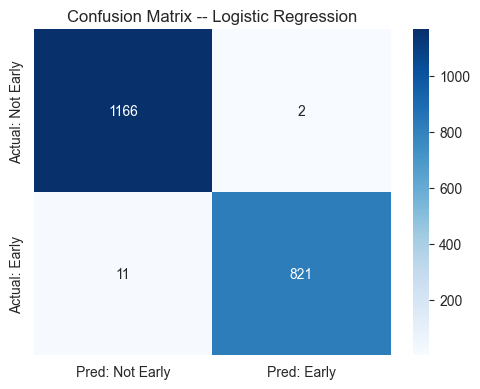

Saved: model_confusion_matrix.png


C:\Users\hp\anaconda3\envs\myenv\lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\hp\anaconda3\envs\myenv\lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


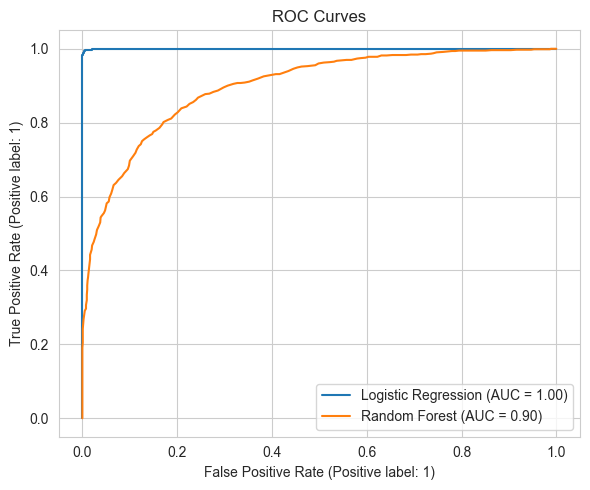

Saved: model_roc_curves.png


In [10]:
# -----------------------------------------------------------------------
# STEP 7: PREDICTIVE MODELLING (secondary task, supports the feature-
# importance side of the research question -- which factors matter most)
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 7: PREDICTIVE MODELLING OF Early_Waker")
print("=" * 70)

# 7a. Define features (X) and target (y). We exclude the outcome variables
# we used above from the feature set, because including them would let the
# model "cheat" by learning the reverse relationship rather than genuinely
# predicting early waking from independent lifestyle/health factors.
feature_cols = [c for c in df.columns if c not in OUTCOMES + [TARGET]]
X = df[feature_cols]
y = df[TARGET]

numeric_features = [c for c in feature_cols if c in numeric_cols]
categorical_features = [c for c in feature_cols if c in categorical_cols]

# 7b. Train/test split, stratified so both sets keep the same class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 7c. Preprocessing pipeline: scale numeric features (important for
# Logistic Regression), one-hot encode categorical features (turns each
# category into its own 0/1 column so models can use it numerically).
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
])

# 7d. Two models: Logistic Regression (simple, interpretable baseline) and
# Random Forest (captures non-linear relationships and interactions).
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}

results_summary = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results_summary.append({
        "model": name,
        "accuracy": round(accuracy_score(y_test, y_pred), 3),
        "precision": round(precision_score(y_test, y_pred), 3),
        "recall": round(recall_score(y_test, y_pred), 3),
        "f1": round(f1_score(y_test, y_pred), 3),
        "roc_auc": round(roc_auc_score(y_test, y_proba), 3),
    })

print(pd.DataFrame(results_summary).to_string(index=False))

# 7e. Confusion matrix and full classification report for the stronger model
best_model_name = max(results_summary, key=lambda r: r["roc_auc"])["model"]
best_pipe = fitted_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)

print(f"\nDetailed report for best model ({best_model_name}):")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Not Early", "Pred: Early"],
            yticklabels=["Actual: Not Early", "Actual: Early"])
plt.title(f"Confusion Matrix -- {best_model_name}")
plt.tight_layout()
plt.savefig("model_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: model_confusion_matrix.png")

# 7f. ROC curve for both models on one plot
plt.figure(figsize=(6, 5))
for name, pipe in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=plt.gca())
plt.title("ROC Curves")
plt.tight_layout()
plt.savefig("model_roc_curves.png", dpi=150)
plt.show()
print("Saved: model_roc_curves.png")


STEP 8: FEATURE IMPORTANCE


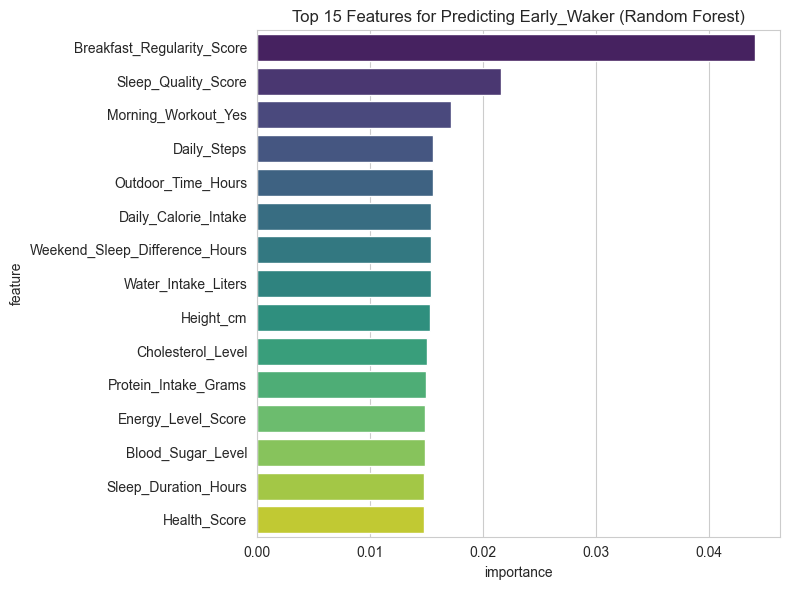

Saved: feature_importance.png
                       feature  importance
    Breakfast_Regularity_Score    0.044062
           Sleep_Quality_Score    0.021592
           Morning_Workout_Yes    0.017184
                   Daily_Steps    0.015561
            Outdoor_Time_Hours    0.015554
          Daily_Calorie_Intake    0.015433
Weekend_Sleep_Difference_Hours    0.015396
           Water_Intake_Liters    0.015357
                     Height_cm    0.015274
             Cholesterol_Level    0.015013
          Protein_Intake_Grams    0.014951
            Energy_Level_Score    0.014894
             Blood_Sugar_Level    0.014825
          Sleep_Duration_Hours    0.014815
                  Health_Score    0.014811


In [11]:
# -----------------------------------------------------------------------
# STEP 8: FEATURE IMPORTANCE -- which lifestyle/health factors matter most
# for distinguishing early wakers from everyone else?
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 8: FEATURE IMPORTANCE")
print("=" * 70)

rf_pipe = fitted_pipelines["Random Forest"]
# Recover the expanded feature names after one-hot encoding, so importances
# can be matched back to a human-readable label
ohe_feature_names = rf_pipe.named_steps["preprocess"] \
    .named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_feature_names)

importances = rf_pipe.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance", y="feature",
            hue="feature", palette="viridis", legend=False)
plt.title("Top 15 Features for Predicting Early_Waker (Random Forest)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Saved: feature_importance.png")
print(importance_df.to_string(index=False))

In [13]:
# -----------------------------------------------------------------------
# STEP 9: PLAIN-LANGUAGE SUMMARY
# -----------------------------------------------------------------------
print("\n" + "=" * 70)
print("STEP 9: SUMMARY -- HOW TO ANSWER THE RESEARCH QUESTION")
print("=" * 70)
print("""
Look at the mediation_df table from Step 6 for each outcome/mediator pair:

- If 'direct_effect_c_prime' is close to zero and much smaller than 'total_effect_c', AND 'mediation_significant' is True, that means early waking's 
  apparent benefit is mostly EXPLAINED AWAY by sleep quality / exercise -- i.e. it's not waking up early itself that helps, it's the better sleep and 
  exercise habits that tend to come with it.

- If 'direct_effect_c_prime' stays large and significant even after controlling for the mediator, that means early waking has an INDEPENDENT 
  association with the outcome beyond just sleep/exercise.

- The feature importance plot (Step 8) gives a complementary view: it shows which variables, including the mediators, are most useful for telling 
  early wakers apart from everyone else in the first place.

Remember to state in your write-up that this is a SYNTHETIC dataset, so these results demonstrate the correct methodology for answering a mediation
question, not a real-world discovery about human sleep behaviour.
""")


STEP 9: SUMMARY -- HOW TO ANSWER THE RESEARCH QUESTION

Look at the mediation_df table from Step 6 for each outcome/mediator pair:

- If 'direct_effect_c_prime' is close to zero and much smaller than 'total_effect_c', AND 'mediation_significant' is True, that means early waking's 
  apparent benefit is mostly EXPLAINED AWAY by sleep quality / exercise -- i.e. it's not waking up early itself that helps, it's the better sleep and 
  exercise habits that tend to come with it.

- If 'direct_effect_c_prime' stays large and significant even after controlling for the mediator, that means early waking has an INDEPENDENT 
  association with the outcome beyond just sleep/exercise.

- The feature importance plot (Step 8) gives a complementary view: it shows which variables, including the mediators, are most useful for telling 
  early wakers apart from everyone else in the first place.

Remember to state in your write-up that this is a SYNTHETIC dataset, so these results demonstrate the correct 